# 03 - Founder patterns (public-data proxy)

**Research question.** Using only public founder data, what can we say about (a) solo vs team founding among unicorns, (b) the most common team sizes, and (c) which sectors and regions are over- or under-covered in public founder records (and what that bias means)?

**Data sources.**
- Unicorn list: CB Insights - <https://www.cbinsights.com/research-unicorn-companies>.
- Founder rows: Wikipedia's `List_of_unicorn_startup_companies` table - <https://en.wikipedia.org/wiki/List_of_unicorn_startup_companies>. This covers roughly 200 of the 1,300+ unicorns - the famous ones.
- For users with API access: OpenVC public founder/investor directory - <https://www.openvc.app/> - and Crunchbase free tier - <https://www.crunchbase.com/>. The fetch script can be extended to pull from either.

Pulled via `scripts/fetch_data.py`. Pull date in `data/raw/_fetch_log.json`.

**Honest data warning - read first.** This notebook is the weakest of the three. Public founder coverage is wildly uneven:
- Wikipedia covers ~15% of the CB Insights unicorn list, heavily   skewed toward US/EU and toward famous companies. Coverage of CN   and IN unicorns is poor.
- "Solo founder" in a public list often means "only one founder is   listed", not "only one human founded the company". Co-founders   who left early are routinely dropped from public bios.
- We do **not** attempt a repeat-founder analysis here. That requires   linking prior-company records and is unreliable on public data alone;   any number we produced would be misleadingly precise.

If you would not be comfortable citing a number in a research seminar, do not cite it from this notebook.


## Reproducibility

The cell below records the package versions and the data-pull metadata that produced everything below. It also installs a hook so every `plt.show()` call also writes the figure to `notebooks/figures/` — that way the PNGs on GitHub are always in sync with the rendered notebook.

In [1]:
# Reproducibility
from __future__ import annotations
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
_log = Path('..') / 'data' / 'raw' / '_fetch_log.json'
_meta = json.loads(_log.read_text())[-1] if _log.exists() else {'date': 'unknown', 'source': 'unknown'}
print(f'python      : {sys.version.split()[0]}')
print(f'pandas      : {pd.__version__}')
print(f'numpy       : {np.__version__}')
print(f'matplotlib  : {matplotlib.__version__}')
print(f'data source : {_meta.get("source")}')
print(f'pull date   : {_meta.get("date")}')
print('notebook    : 03_founder_patterns_proxy')

_FIG_SLUG = '03_founder_patterns_proxy'
_FIG_DIR = Path('figures'); _FIG_DIR.mkdir(parents=True, exist_ok=True)
_FIG_COUNTER = {'n': 0}
_orig_show = plt.show
def _show_and_save(*a, **kw):
    for num in plt.get_fignums():
        _FIG_COUNTER['n'] += 1
        fig = plt.figure(num)
        out = _FIG_DIR / f'{_FIG_SLUG}_fig{_FIG_COUNTER["n"]}.png'
        fig.savefig(out, dpi=140, bbox_inches='tight')
    return _orig_show(*a, **kw)
plt.show = _show_and_save


python      : 3.10.12
pandas      : 2.3.3
numpy       : 2.2.6
matplotlib  : 3.10.8
data source : cbinsights
pull date   : 2026-05-16
notebook    : 03_founder_patterns_proxy


In [2]:
from __future__ import annotations
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')


## 1. Load data

Expects `data/raw/unicorns.csv` and `data/raw/founders.csv` (long-form: one row per `(company, founder_name)`). Both are produced by `scripts/fetch_data.py`.


In [3]:
RAW = Path('..') / 'data' / 'raw'
LOG = RAW / '_fetch_log.json'
uni_path = RAW / 'unicorns.csv'
fnd_path = RAW / 'founders.csv'

if not uni_path.exists():
    raise FileNotFoundError(f'{uni_path} not found. Run `python scripts/fetch_data.py`.')

df = pd.read_csv(uni_path)
pull_meta = json.loads(LOG.read_text())[-1] if LOG.exists() else {'date': 'unknown', 'source': 'unknown'}
print(f"Unicorn list: {len(df):,} rows ({pull_meta['source']}, pulled {pull_meta['date']}).")

if fnd_path.exists():
    fnd = pd.read_csv(fnd_path)
    print(f"Founder file: {len(fnd):,} rows, {fnd['company'].nunique()} unique companies.")
    HAS_FOUNDERS = True
else:
    fnd = None
    HAS_FOUNDERS = False
    print('No founders.csv. Re-run scripts/fetch_data.py.')


Unicorn list: 1,356 rows (cbinsights, pulled 2026-05-16).
Founder file: 423 rows, 206 unique companies.


## 2. Public-founder coverage of the unicorn list

Before any founder statistic, look at coverage. If only 15% of unicorns have a public founder record, all downstream numbers describe that 15%, not the unicorn population.


In [4]:
if not HAS_FOUNDERS:
    raise RuntimeError('Re-run scripts/fetch_data.py to produce founders.csv.')

covered = set(fnd['company'].astype(str).str.strip())
df['has_founder_record'] = df['company'].astype(str).str.strip().isin(covered)

coverage = df.groupby('country')['has_founder_record'].agg(['mean', 'size'])
coverage = coverage.rename(columns={'mean': 'share_covered', 'size': 'n_unicorns'})
coverage = coverage[coverage['n_unicorns'] >= 15].sort_values('share_covered', ascending=False)
coverage.head(15).style.format({'share_covered': '{:.0%}', 'n_unicorns': '{:.0f}'}) if hasattr(coverage, 'style') else coverage.head(15)


,share_covered,n_unicorns
country,,
India,0.269841,63
Germany,0.142857,35
United States,0.120051,783
United Kingdom,0.114754,61
Canada,0.090909,22
Israel,0.080000,25
Singapore,0.062500,16
France,0.032258,31
China,0.025974,154


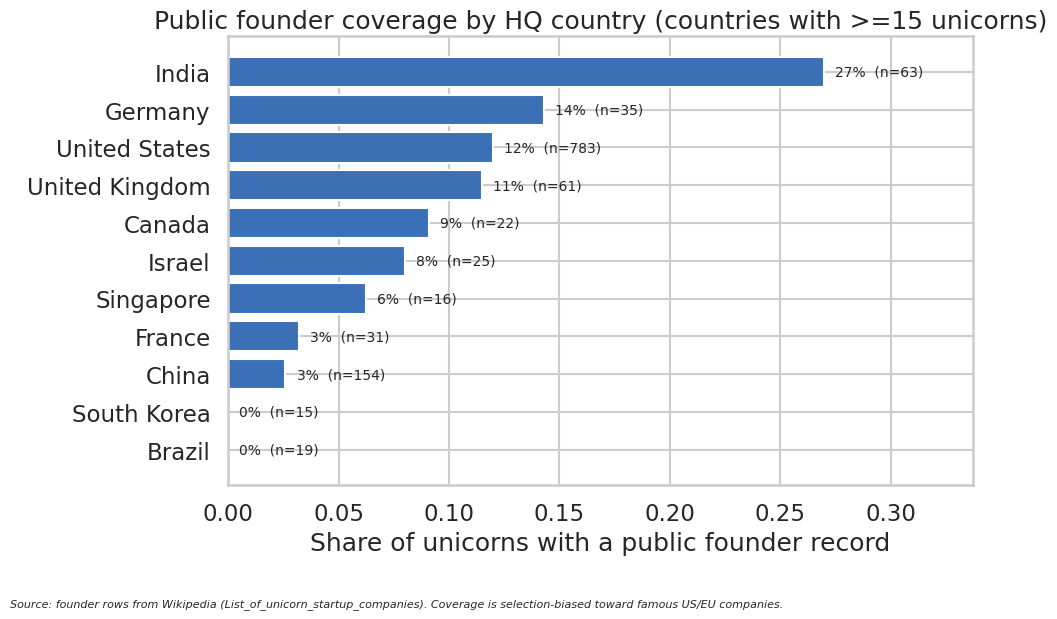

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
cov_plot = coverage.head(12).sort_values('share_covered')
ax.barh(cov_plot.index, cov_plot['share_covered'], color='#3b6fb6')
for i, (share, n) in enumerate(zip(cov_plot['share_covered'], cov_plot['n_unicorns'])):
    ax.text(share + 0.005, i, f'{share:.0%}  (n={int(n)})',
            va='center', fontsize=10)
ax.set_xlim(0, max(cov_plot['share_covered']) * 1.25)
ax.set_xlabel('Share of unicorns with a public founder record')
ax.set_title('Public founder coverage by HQ country (countries with >=15 unicorns)')
fig.text(0.01, -0.04,
         'Source: founder rows from Wikipedia (List_of_unicorn_startup_companies). '
         'Coverage is selection-biased toward famous US/EU companies.',
         fontsize=8, style='italic')
plt.tight_layout()
plt.show()


## 3. Founder team size - on the covered subsample only

Among companies for which a public founder record exists, what is the distribution of listed-founder counts? Note: 1 listed founder does **not** equal 1 actual founder; co-founders who left early are routinely dropped from public lists.


In [6]:
team_size = fnd.groupby('company').size().rename('n_founders')
team_size_buckets = pd.cut(
    team_size, bins=[0, 1, 2, 3, np.inf],
    labels=['1 (listed solo)', '2', '3', '4+'],
)
share = team_size_buckets.value_counts(normalize=True).reindex(
    ['1 (listed solo)', '2', '3', '4+']
).fillna(0)

print(f'Companies with at least one founder listed: {team_size.size:,}')
print(share.to_frame('share').map(lambda x: f'{x:.1%}'))


Companies with at least one founder listed: 206
                 share
n_founders            
1 (listed solo)  36.4%
2                35.4%
3                18.4%
4+                9.7%


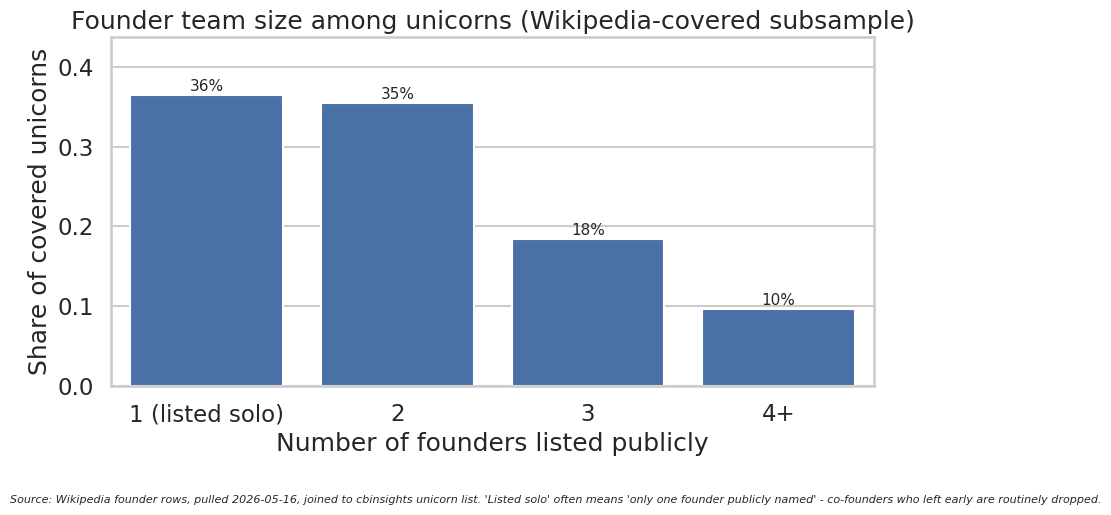

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=share.index, y=share.values, color='#3b6fb6', ax=ax)
for i, v in enumerate(share.values):
    ax.text(i, v + 0.005, f'{v:.0%}', ha='center', fontsize=11)
ax.set_ylim(0, max(share.values) * 1.2)
ax.set_xlabel('Number of founders listed publicly')
ax.set_ylabel('Share of covered unicorns')
ax.set_title('Founder team size among unicorns (Wikipedia-covered subsample)')
fig.text(0.01, -0.04,
         f"Source: Wikipedia founder rows, pulled {pull_meta['date']}, joined to "
         f"{pull_meta['source']} unicorn list. 'Listed solo' often means 'only one "
         "founder publicly named' - co-founders who left early are routinely dropped.",
         fontsize=8, style='italic')
plt.tight_layout()
plt.show()


## 4. Sector mix of covered vs uncovered unicorns

Quick sanity check: are public founder records over-representing certain sectors? If so, the team-size statistic above is conditional on that mix.


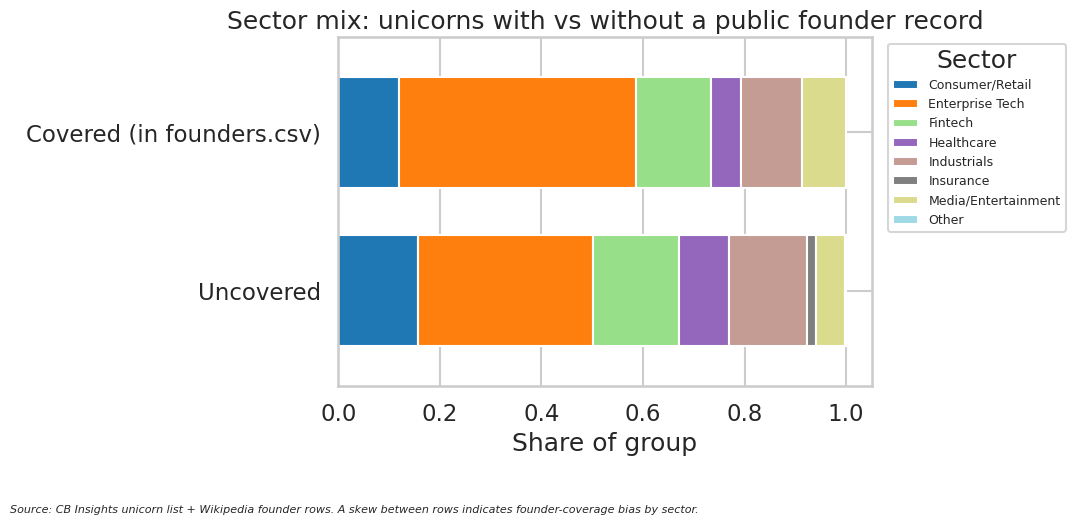

In [8]:
SECTOR_MAP = {
    'Enterprise Tech': 'Enterprise Tech',
    'Financial Services': 'Fintech',
    'Consumer & Retail': 'Consumer/Retail',
    'Industrials': 'Industrials',
    'Healthcare & Life Sciences': 'Healthcare',
    'Media & Entertainment': 'Media/Entertainment',
    'Insurance': 'Insurance',
}
df['sector_grp'] = df['sector'].map(SECTOR_MAP).fillna('Other')

mix = (
    df.groupby(['has_founder_record', 'sector_grp'])
      .size().unstack(fill_value=0)
)
mix_share = mix.div(mix.sum(axis=1), axis=0)
mix_share.index = ['Uncovered', 'Covered (in founders.csv)']

fig, ax = plt.subplots(figsize=(11, 5))
mix_share.plot(kind='barh', stacked=True, ax=ax, colormap='tab20', width=0.7)
ax.set_xlabel('Share of group')
ax.set_ylabel('')
ax.set_title('Sector mix: unicorns with vs without a public founder record')
ax.legend(title='Sector', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
fig.text(0.01, -0.06,
         'Source: CB Insights unicorn list + Wikipedia founder rows. '
         'A skew between rows indicates founder-coverage bias by sector.',
         fontsize=8, style='italic')
plt.tight_layout()
plt.show()


## What this cannot tell us

- **Anything causal about founder traits and outcomes.** We see only   surviving unicorns. We cannot say "solo founders are X% less likely   to scale" - that requires the denominator of all founders.
- **Cross-region comparison.** Founder coverage is much better for US/EU   than for CN/IN. Any cross-region team-size statistic is contaminated   by differential reporting.
- **True team size.** Public lists drop co-founders who left within   the first 1-2 years. Our "listed solo" share is almost certainly an   over-estimate of true solo founding.
- **Repeat-founder share.** We did not attempt this. Linking prior   ventures from public data is unreliable; any number would be   misleadingly precise.
- **Founder demographics.** Gender, ethnicity, education - none of   these are encoded in public sources in a way that supports honest   measurement at this scale. Hand-coded sub-samples are the right tool.

If you want to push on founder questions seriously, the right move is a structured hand-coded subsample on a fixed frame, not more regex-on-public-bios.


## Save figures

Figures are auto-persisted by the `plt.show` hook installed in the Reproducibility cell at the top. The cell below just lists what was written so the run is self-documenting. Plotly figures are interactive and not exported here.

In [9]:
# Save key figures
from pathlib import Path
_slug = '03_founder_patterns_proxy'
_written = sorted(Path('figures').glob(f'{_slug}_fig*.png'))
print(f'{len(_written)} figure(s) saved to notebooks/figures/ for {_slug}:')
for p in _written:
    print(f'  {p}')


3 figure(s) saved to notebooks/figures/ for 03_founder_patterns_proxy:
  figures/03_founder_patterns_proxy_fig1.png
  figures/03_founder_patterns_proxy_fig2.png
  figures/03_founder_patterns_proxy_fig3.png
